# Multi-Layer Deep Feature: Extraction & Evaluation

> **Naming note:** We call the method implemented in this notebook **Multi-Layer
> Deep Feature (MLDF)**. It is *not* PatchCore (Roth et al., CVPR 2022 —
> arXiv:2106.08265): PatchCore keeps the spatial patch grid from intermediate
> feature maps and builds a memory bank of local patch descriptors for
> pixel-level localisation, whereas this notebook **globally average-pools**
> each layer into a single vector per image. It is also not a direct
> reproduction of DN2 or SPADE (which each use a *single* feature layer) —
> ours concatenates **two** layers into one representation before scoring.

### What is different from previous work

This notebook goes back to the raw images and extracts features from **two intermediate
layers** of a pretrained CNN (WideResNet50) combining
multiple layers: earlier layers keep fine local detail (edges, texture, unusual
structure); later layers keep higher-level semantics. Combining both gives a richer,
multi-scale representation but each layer is still collapsed to one vector per image,
so this remains an **image-level** method, not a patch-level one.

### Pipeline overview

```
Raw .png images
      ↓
WideResNet50 pretrained on ImageNet  (FROZEN — no training)
      ├─ Layer 2 → (512-dim) local structure
      └─ Layer 3 → (1024-dim) semantic content
      ↓
Global average pool each layer → L2-normalise → concatenate → 1536-dim per image
      ↓
Whiten (StandardScaler)
      ↓
Memory bank (all feature vectors stored)
      ↓
k-NN anomaly score: mean distance to k nearest neighbours   (Multi-Layer Deep Feature)
      ↓
Evaluate: ROC-AUC, PR-AUC, Recall@100, Spearman
      ↓
Compare against Protege baseline
```


### Report-framing note

Because this is a **third, distinct method** (not a mislabelled DN2/SPADE or
PatchCore run), the LaTeX report's framing needs to describe **three**
approaches, not two: DN2/SPADE-style single-layer scoring, this multi-layer
GAP-based method (MLDF), and the separate true PatchCore implementation
(`patchcore_real_implementation.ipynb`) with its patch-level memory bank.
The "opposite ends of a cost/capability trade-off" narrative should be
updated to place MLDF as an intermediate point between the two, not folded
into either one.


## 1. Helper Functions

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    pairwise_distances_chunked
)


BASE_DIR = Path.cwd().parent

# Data loading

def load_catalogue():
    path = BASE_DIR / "data" / "protege_catalogue.csv"
    df = pd.read_csv(path)
    print(f"Catalogue loaded: {df.shape}")
    return df

# Metrics

def compute_metrics(y_true, scores):
    """Return ROC-AUC and PR-AUC."""
    return {
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
    }


# Device

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

Device : cpu
PyTorch: 2.7.1+cu126


In [25]:
def compute_ind_sum(found_inds, all_inds):
    this_found_inds = sorted(found_inds)
    out = np.zeros(len(all_inds))
    for i in this_found_inds:
        out[i:] += 1
    return out


def cumulative_sum(anomaly_scores, labels):
    """Running count of true anomalies as we walk down the ranked list."""
    sorted_inds = anomaly_scores.sort_values(ascending=False).index
    labs        = labels.loc[anomaly_scores.index]
    anom_inds   = labs[labs == 1].index
    found_inds  = []
    for i in anom_inds:
        pos = np.where(sorted_inds == i)[0]
        if len(pos) > 0:
            found_inds.append(pos[0])
    return compute_ind_sum(found_inds, sorted_inds)


def topk_recall(y_true, scores, k=100):
    """Fraction of true anomalies found in the top-k ranked candidates."""
    ranked = scores.sort_values(ascending=False).index[:k]
    return y_true.loc[ranked].sum() / y_true.sum()


def evaluate(name, scores, y_true, labels_raw):
    """Return one result row in the standard format."""
    m = compute_metrics(y_true, scores)
    return {
        'Method':           name,
        'ROC-AUC (4-5)':    round(m['roc_auc'], 4),
        'PR-AUC (4-5)':     round(m['pr_auc'],  4),
        'Recall@100 (4-5)': round(topk_recall(y_true, scores), 4),
        'Spearman (1-5)':   round(labels_raw.corr(scores, method='spearman'), 4),
    }


def show_results(methods_dict, y_true, labels_raw):
    """Standard evaluation table sorted by ROC-AUC."""
    rows = [evaluate(n, s, y_true, labels_raw)
            for n, s in methods_dict.items()]
    df = pd.DataFrame(rows).set_index('Method')
    display(df.sort_values('ROC-AUC (4-5)', ascending=False))
    return df


def discovery_plot(methods_dict, y_true, highlight=None):
    """Standard cumulative discovery curve."""
    colors     = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#8c564b',
                  '#e377c2','#17becf','#9467bd','#bcbd22','#e74c3c']
    linestyles = ['-','--','-.', ':','-','-.','--',':','-.','--']

    fig, ax = plt.subplots(figsize=(8, 5))
    for (name, scores), c, ls in zip(methods_dict.items(), colors, linestyles):
        lw  = 2.4 if (highlight and name in highlight) else 1.3
        cum = cumulative_sum(scores, y_true)
        ax.plot(cum, label=name, color=c, linestyle=ls, linewidth=lw)
    ax.set_xlabel('Index in list ordered by algorithm score')
    ax.set_ylabel('Number of anomalies found')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 3. Load Catalogue and Baseline

In [26]:
# Load catalogue (defines the FULL corpus -- every object we will try to
# extract features for).
cat = load_catalogue()

# Restrict to objects that were actually human-scored in the evaluation
# subset. evaluation_subset_author_ML_score == -1 means "never scored" --
# these are NOT confirmed negatives and must be excluded, not folded into
# the negative class.
#
# IMPORTANT: `labelled_ids` is derived purely from the catalogue and is
# used only for AUC / PR-AUC / Recall@100 scoring later. It must NOT be
# used to restrict which objects get images discovered or features
# extracted in Sections 4-7 below -- feature extraction runs over the FULL
# catalogue, and labels only enter at evaluation time (Section 8 onward).
cat_eval = cat[cat['evaluation_subset_author_ML_score'] != -1].copy()

labelled_ids = cat_eval['objid']
cat_eval     = cat_eval.set_index('objid').loc[labelled_ids]

labels        = cat_eval['evaluation_subset_author_ML_score']
y_interesting = (labels >= 4).astype(int)

# Protege baseline score -- our gold standard comparison (eval subset only)
protege_scores = cat_eval['protege_score']
protege_scores.name = 'score'

print(f'Full corpus (catalogue)      : {cat["objid"].nunique()} objects')
print(f'Labelled evaluation subset   : {len(labelled_ids)} objects')
print(f'Anomalies: {y_interesting.sum()} / {len(y_interesting)} (score ≥ 4)')
print(f'Prevalence: {y_interesting.mean():.2%}')

# ── Sanity check: two DIFFERENT counts, both expected ─────────────────────
# 6,161  = the FULL dataset (every object in protege_catalogue.csv). This
#          drives feature extraction (Sections 4-7) and Condition B's
#          memory bank (Section 14).
# 1,031  = the EVALUATION SUBSET, i.e. objects with a real human
#          (evaluation_subset_author_ML_score != -1) Protege score. This is
#          the labelled set used for AUC/PR-AUC/Recall@100/Spearman scoring,
#          and Condition A's memory bank (Sections 11-13).
# These are not meant to match -- confirmed expected, not a data-drift bug.
assert cat['objid'].nunique() == 6161, (
    f"Full corpus count changed from the expected 6161 -- check whether "
    f"protege_catalogue.csv was updated (got {cat['objid'].nunique()})."
)
assert len(labelled_ids) == 1031, (
    f"Evaluation subset count changed from the expected 1031 -- check "
    f"whether protege_catalogue.csv was updated (got {len(labelled_ids)})."
)
print('\nSanity check passed: full dataset = 6161, evaluation subset = 1031 (both as expected).')


Catalogue loaded: (6161, 12)
Full corpus (catalogue)      : 6161 objects
Labelled evaluation subset   : 1031 objects
Anomalies: 86 / 1031 (score ≥ 4)
Prevalence: 8.34%

Sanity check passed: full dataset = 6161, evaluation subset = 1031 (both as expected).


In [27]:
# Sanity check: should now show only the 5 real score classes (1-5), no -1
print(labels.value_counts().sort_index())


evaluation_subset_author_ML_score
1    384
2    439
3    122
4     62
5     24
Name: count, dtype: int64


## 4. Discover Images

Images are stored in two folders under `data/images/`.
We build an `objid → file path` mapping, then check alignment with the catalogue.


In [28]:
IMAGE_DIRS = [
    BASE_DIR / 'data' / 'images' / 'all_images_compressed_part1',
    BASE_DIR / 'data' / 'images' / 'all_images_compressed_part2',
]

# ── Key fact (from the README) ────────────────────────────────────────────────
# The .png filenames are the PROTEGE RANK of each object.
# 0.png = the object Protege ranked #0 (highest anomaly score)
# 1.png = rank #1, and so on.
# The catalogue has a 'protege_rank' column that holds these integers.

# Build integer protege_rank → Path mapping
image_map_int = {}
for d in IMAGE_DIRS:
    if not d.exists():
        print(f'WARNING: {d} not found')
        continue
    for p in d.glob('*.png'):
        image_map_int[int(p.stem)] = p

print(f'Total images found       : {len(image_map_int)}')
print(f'Protege rank range       : {min(image_map_int)} – {max(image_map_int)}')

# Build objid → Path using protege_rank column.
# Iterates over the FULL catalogue (cat), not cat_eval, so every object --
# labelled or not -- gets a chance at an image.
image_map = {}
for _, row in cat.iterrows():
    rank  = int(row['protege_rank'])
    objid = row['objid']
    if rank in image_map_int:
        image_map[objid] = image_map_int[rank]

print(f'Mapped objids → images   : {len(image_map)}')

# Corpus is defined by the CATALOGUE.
objids_all     = list(cat['objid'])
objids_found   = [oid for oid in objids_all if oid in image_map]
objids_missing = [oid for oid in objids_all if oid not in image_map]

print(f'Objects in catalogue     : {len(objids_all)}')
print(f'Objects with images      : {len(objids_found)}')
print(f'Objects missing images   : {len(objids_missing)}')

if objids_missing:
    print(f'  First 3 missing objids : {objids_missing[:3]}')


Total images found       : 6161
Protege rank range       : 0 – 6160
Mapped objids → images   : 6161
Objects in catalogue     : 6161
Objects with images      : 6161
Objects missing images   : 0


### Preview Sample Images

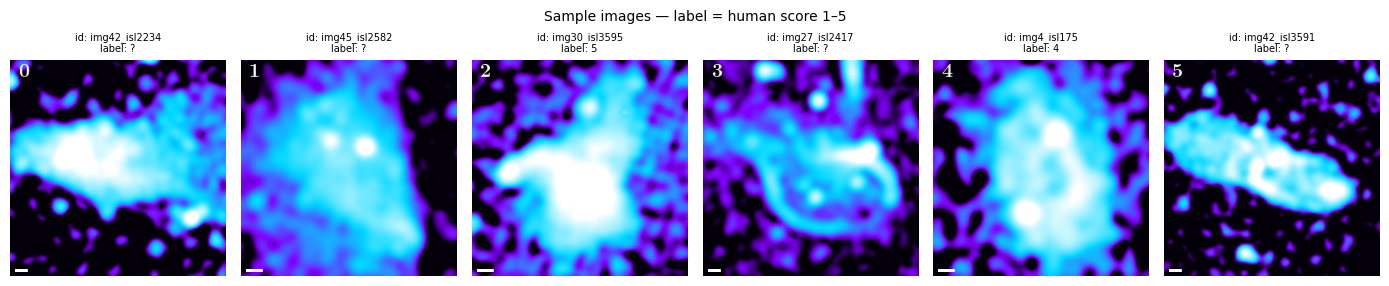

In [29]:
sample_ids = objids_found[:6]

fig, axes = plt.subplots(1, len(sample_ids), figsize=(14, 3))
for ax, oid in zip(axes, sample_ids):
    img = Image.open(image_map[oid]).convert('RGB')
    lbl = labels.loc[oid] if oid in labels.index else '?'
    ax.imshow(img)
    ax.set_title(f'id: {oid}\nlabel: {lbl}', fontsize=7)
    ax.axis('off')
plt.suptitle('Sample images — label = human score 1–5', fontsize=10)
plt.tight_layout()
plt.show()


## 5. Multi-Layer Feature Extractor

We use **WideResNet50_2** pretrained on ImageNet as a frozen feature extractor.
This follows the general recipe of the DN2 / SPADE line of work -- reusing an
ImageNet-pretrained backbone without any fine-tuning and scoring with k-NN --
but we concatenate **two** layers (not one), so we call the resulting method
**Multi-Layer Deep Feature** rather than DN2 or SPADE specifically.

### Why WideResNet50?
- Common backbone choice in deep nearest-neighbor anomaly detection work (DN2, SPADE, PatchCore all use ResNet-family backbones)
- Pretrained on ImageNet — strong general visual features
- Wide architecture (2× channels) captures more detail than standard ResNet50

### Why these two layers?

| Layer | Output channels | What it captures |
|---|---|---|
| `layer2` | 512 | Local texture, edges, spatial patterns, unusual morphology |
| `layer3` | 1024 | Higher-level semantic content, global structure |

Here, each layer's spatial feature map is collapsed to **one vector per image** using
**global average pooling**, then **L2-normalised** independently. Final concatenated vector: 512 + 1024 =
**1536 dimensions per image**.

The network weights are **never updated** we only do a forward pass.


In [30]:
class MultiLayerExtractor:
    """
    Extracts 1536-dim multi-layer features from images using frozen WideResNet50.

    Architecture:
        image (3×224×224)
            ↓  WideResNet50 (frozen)
            ├─ layer2 → pool → L2-norm → 512-dim
            └─ layer3 → pool → L2-norm → 1024-dim
            ↓  concatenate
        feature vector (1536-dim)

    No training — only inference (one forward pass per image).
    """

    def __init__(self, device):
        self.device = device

        # Load WideResNet50 pretrained on ImageNet
        backbone = models.wide_resnet50_2(
            weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1
        )
        backbone.eval()
        for p in backbone.parameters():
            p.requires_grad = False     # freeze all weights

        # Sub-network up to layer2 (local features, 512 channels)
        self.layer2_net = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2
        ).to(device)

        # Sub-network up to layer3 (semantic features, 1024 channels)
        self.layer3_net = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3
        ).to(device)

        # Global average pool: (C, H, W) → (C,)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # ImageNet normalisation — required for pretrained weights
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            # Radio images are single-channel — replicate to 3 channels
            T.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
        ])

    def extract_batch(self, image_paths: list) -> np.ndarray:
        """
        Extract 1536-dim features for a list of image file paths.
        Returns np.ndarray of shape (N, 1536).
        """
        tensors = []
        for p in image_paths:
            try:
                img = Image.open(p).convert('RGB')
                tensors.append(self.transform(img))
            except Exception as e:
                print(f'  WARNING: could not load {p}: {e}')
                tensors.append(torch.zeros(3, 224, 224))

        batch = torch.stack(tensors).to(self.device)

        with torch.no_grad():
            # (N, 512, H2, W2) → pool → (N, 512)
            f2 = self.pool(self.layer2_net(batch)).squeeze(-1).squeeze(-1)
            # (N, 1024, H3, W3) → pool → (N, 1024)
            f3 = self.pool(self.layer3_net(batch)).squeeze(-1).squeeze(-1)

        f2 = f2.cpu().numpy()
        f3 = f3.cpu().numpy()

        # L2-normalise each layer independently
        f2_norm = normalize(f2, norm='l2')   # (N, 512)
        f3_norm = normalize(f3, norm='l2')   # (N, 1024)

        return np.concatenate([f2_norm, f3_norm], axis=1)   # (N, 1536)


extractor = MultiLayerExtractor(device)
print('Extractor ready.')
print('Output: 512 (layer2) + 1024 (layer3) = 1536 dims per image')


Extractor ready.
Output: 512 (layer2) + 1024 (layer3) = 1536 dims per image


## 7. Extract Features for All Images

Process every image in batches and save to disk.
The result is a parquet file saved to `data/multi_layer_deep_feature_full.parquet`

**Caching:** if the file already exists, it is loaded directly —
you never need to re-run the extraction.


In [31]:
BATCH_SIZE   = 32
SAVE_PATH    = BASE_DIR / 'data' / 'multi_layer_deep_feature_full.parquet'

# ── Delete corrupted or stale cache if it exists ──────────────────────────────
# Renamed from patchcore_features_v3.parquet: that cache was built while
# the corpus list was (incorrectly) pre-filtered to the ~1031-object
# labelled eval subset, so any old cache under the old name is silently
# the wrong corpus. A fresh filename forces a real full-corpus extraction
# the first time this runs on ilifu. We also check the row count against objids_found, so a
# stale/partial cache under this new name gets caught too.
if SAVE_PATH.exists():
    try:
        df_pc_features = pd.read_parquet(SAVE_PATH)
        if len(df_pc_features) < len(objids_found):
            print(f'Cache has {len(df_pc_features)} rows but {len(objids_found)} '
                  f'images were found -- stale/partial cache, re-extracting...')
            SAVE_PATH.unlink()
        else:
            print(f'Loaded: {df_pc_features.shape}  (objects × feature dims)')
    except Exception as e:
        print(f'Corrupted cache detected ({e}), deleting and re-extracting...')
        SAVE_PATH.unlink()

# ── Extract if no valid cache ──────────────────────────────────────────────────
if not SAVE_PATH.exists():
    print(f'Extracting features for {len(objids_found)} images (full corpus)...')
    print(f'Batch size : {BATCH_SIZE}')
    print(f'Save path  : {SAVE_PATH}')
    print()

    all_feats  = []
    all_objids = []

    for start in range(0, len(objids_found), BATCH_SIZE):
        batch_ids   = objids_found[start : start + BATCH_SIZE]
        batch_paths = [image_map[oid] for oid in batch_ids]
        feats = extractor.extract_batch(batch_paths)   # (B, 1536)
        all_feats.append(feats)
        all_objids.extend(batch_ids)

        n_done = min(start + BATCH_SIZE, len(objids_found))
        print(f'  {n_done:4d} / {len(objids_found)} images processed', end='\r')

    print()
    arr = np.vstack(all_feats)
    df_pc_features = pd.DataFrame(arr, index=all_objids)
    df_pc_features.index.name = 'objid'
    df_pc_features.to_parquet(SAVE_PATH)
    print(f'\nSaved to {SAVE_PATH}')
    print(f'Feature matrix: {df_pc_features.shape}')


Loaded: (6161, 1536)  (objects × feature dims)


## 8. Align with Evaluation Set

Some catalogue objects may not have images.
We restrict the evaluation to the intersection — objects with both
a catalogue label and an extracted multi-layer feature vector.


In [32]:
# Intersection of the labelled evaluation subset (Section 3) and objects
# with extracted Multi-Layer Deep Feature features (Section 7). `labelled_ids` is
# independent of extraction -- some catalogue objects may lack images or
# features, so we align here rather than assuming full coverage.
eval_ids = [oid for oid in labelled_ids if oid in df_pc_features.index]

X_pc              = df_pc_features.loc[eval_ids]    # multi-layer (Multi-Layer Deep Feature) features
y_pc              = y_interesting.loc[eval_ids]     # binary labels
labels_pc         = labels.loc[eval_ids]            # raw 1-5 labels
protege_scores_pc = protege_scores.loc[eval_ids]    # Protege baseline (same subset)

excluded = len(labelled_ids) - len(eval_ids)

print(f'Full extracted corpus       : {len(df_pc_features)} objects')
print(f'Labelled evaluation subset  : {len(labelled_ids)} objects')
print(f'  with extracted features   : {len(eval_ids)}')
print(f'Excluded (no image/feature) : {excluded}')
print(f'Interesting (≥ 4)           : {y_pc.sum()} / {len(y_pc)}')
print(f'Feature dimensions          : {X_pc.shape[1]}')


Full extracted corpus       : 6161 objects
Labelled evaluation subset  : 1031 objects
  with extracted features   : 1031
Excluded (no image/feature) : 0
Interesting (≥ 4)           : 86 / 1031
Feature dimensions          : 1536


## 9. Whiten the Features

The 1024-dim layer3 block contributes 1024 dimensions to every Euclidean distance,
while layer2 contributes only 512. Without whitening, layer3 would dominate
every distance calculation simply because it has more dimensions.

`StandardScaler` sets the mean and variance of every dimension to 0 and 1.
After whitening, both layers contribute equally to nearest-neighbour distances.


In [33]:
# Fit the scaler on the FULL extracted corpus (all objects, e.g. 6131), not
# just the labelled eval subset. This is what makes the two evaluation
# conditions used later in the notebook comparable on equal footing:
#   Condition A (Sections 11-13): memory bank = labelled eval subset only
#       -- mirrors simulate_human_labelling.ipynb from the reference
#       mgcls.protege repo, which restricts `features` to the labelled
#       evaluation subset before scoring.
#   Condition B (Section 14):     memory bank = full extracted corpus
#       (all objects, including unlabelled ones).
# Fitting a separate scaler per condition would confound the bank-size
# comparison with a whitening difference -- one scaler, fit once, reused
# everywhere downstream.
whitener        = StandardScaler()
X_full_whitened = whitener.fit_transform(df_pc_features.values)
X_full_whitened = pd.DataFrame(X_full_whitened, index=df_pc_features.index)

X_pc_whitened = X_full_whitened.loc[eval_ids].values   # eval-subset slice, same transform

print(f'Full corpus shape   : {df_pc_features.shape}')
print(f'Eval-subset shape   : {X_pc.shape}')
print(f'After whiten (full) : {X_full_whitened.shape}')
print(f'After whiten (eval) : {X_pc_whitened.shape}')
print(f'Mean (first 5 dims, full corpus): {X_full_whitened.values[:, :5].mean(axis=0).round(4)}  (should be ~0)')
print(f'Std  (first 5 dims, full corpus): {X_full_whitened.values[:, :5].std(axis=0).round(4)}   (should be ~1)')
print('Note: the eval-subset slice is NOT independently re-centred to mean 0 / std 1 --')
print('it reuses the full-corpus scaler by design (see note above).')


Full corpus shape   : (6161, 1536)
Eval-subset shape   : (1031, 1536)
After whiten (full) : (6161, 1536)
After whiten (eval) : (1031, 1536)
Mean (first 5 dims, full corpus): [0. 0. 0. 0. 0.]  (should be ~0)
Std  (first 5 dims, full corpus): [1. 1. 1. 1. 1.]   (should be ~1)
Note: the eval-subset slice is NOT independently re-centred to mean 0 / std 1 --
it reuses the full-corpus scaler by design (see note above).


## 10. Build the Memory Bank

The memory bank stores all feature vectors.
At scoring time, each object's anomaly score is the **mean distance to its k
nearest neighbours** in the bank — objects unlike anything in the bank are anomalous.

For datasets larger than ~10,000 objects, reduce `subsample_ratio`
(e.g. 0.1) to use greedy coreset subsampling instead of keeping all points.


In [34]:
def build_memory_bank(features: np.ndarray,
                      subsample_ratio: float = 1.0,
                      random_state: int = 42) -> np.ndarray:
    """
    Build the Multi-Layer Deep Feature-style memory bank.

    subsample_ratio=1.0 keeps all points (fine for small datasets).
    For large datasets, greedy coreset subsampling selects a maximally
    spread-out subset: each new point is the one furthest from all
    already-selected points.
    """
    N = len(features)
    n_select = max(1, int(N * subsample_ratio))

    if n_select >= N:
        print(f'Memory bank: keeping all {N} points')
        return features.copy()

    rng      = np.random.default_rng(random_state)
    selected = [int(rng.integers(N))]
    min_dist = np.full(N, np.inf)

    for step in range(1, n_select):
        last     = features[selected[-1]:selected[-1]+1]
        dists    = np.linalg.norm(features - last, axis=1)
        min_dist = np.minimum(min_dist, dists)
        selected.append(int(np.argmax(min_dist)))
        if (step + 1) % 200 == 0 or step == n_select - 1:
            print(f'  Coreset: {step+1}/{n_select}', end='\r')

    print()
    print(f'Memory bank: {len(selected)} / {N} points ({len(selected)/N:.1%})')
    return features[np.array(selected)]


memory_bank = build_memory_bank(X_pc_whitened, subsample_ratio=1.0)
print(f'Memory bank shape: {memory_bank.shape}')


Memory bank: keeping all 1031 points
Memory bank shape: (1031, 1536)


## 11. Anomaly Scoring

Before committing to a single k, we score **every representation**
(layer2, layer3, combined) across the **full k grid** (k = 1, 3, 5, 10).

This matters because the earlier version of this notebook tuned k only on the
*combined* (1536-dim) features, then reused that same k for the layer2-only
and layer3-only ablations in Section 13. That biases the ablation: a k tuned
for one feature space is not guaranteed to be optimal for a different one,
so the layer-only variants could look artificially weak (or strong) purely
because of the mismatched k — not because of the features themselves.

The grid below scores all three representations independently at every k,
so each representation's own optimum is used everywhere downstream.

**This is Condition A.** The memory bank here is the labelled evaluation
subset only (query and bank are the same set of objects) — this
mirrors `simulate_human_labelling.ipynb` in the reference `mgcls.protege`
repo, which restricts `features` to the evaluation subset (`features =
features.loc[inds]`) before running its GP active-learning simulation.
Feature *extraction* (Sections 4-7) still ran over the full corpus; only
the *bank* is restricted here. Condition B — bank built from the full
extracted corpus (all objects) — is evaluated afterward, in Section 14.


In [35]:
def knn_scores(query: np.ndarray,
               memory: np.ndarray,
               k: int = 3,
               query_ids=None,
               bank_ids=None) -> np.ndarray:
    """
    Mean distance to k nearest neighbours in memory bank.
    Uses chunked computation to keep memory usage low.

    If query_ids and bank_ids are given (aligned with query/memory rows),
    self-matches -- a query object that is ALSO present in the memory bank
    -- are excluded by index identity, not by a distance threshold. A
    self-match is an exact distance-zero neighbour and, left in, dominates
    small-k scores (k=1 degenerates to 0 for every self-matched query) and
    dilutes larger-k scores. This matters here because Condition A's bank
    IS the eval subset (query == bank) and Condition B's bank is the full
    corpus, which contains the eval subset.
    """
    N      = len(query)
    scores = np.empty(N)
    done   = 0

    exclude_self = query_ids is not None and bank_ids is not None
    if exclude_self:
        bank_ids_arr = np.asarray(bank_ids)

    for chunk_dists in pairwise_distances_chunked(
            query, memory, metric='euclidean',
            n_jobs=-1, working_memory=256):
        n_chunk = chunk_dists.shape[0]

        if exclude_self:
            chunk_query_ids = np.asarray(query_ids[done:done + n_chunk])
            self_mask = chunk_query_ids[:, None] == bank_ids_arr[None, :]
            chunk_dists = chunk_dists.copy()
            chunk_dists[self_mask] = np.inf

        k_actual = min(k, chunk_dists.shape[1])
        topk     = np.partition(chunk_dists, k_actual - 1, axis=1)[:, :k_actual]
        scores[done : done + n_chunk] = topk.mean(axis=1)
        done += n_chunk
        print(f'  Scoring: {done}/{N}', end='\r')

    print()
    return scores


# ── Representation × k grid search (eval-subset memory bank) ─────────────────
REPRESENTATIONS = {
    'layer2':   (0, 512),      # WideResNet50 layer2, 512-dim
    'layer3':   (512, 1536),   # WideResNet50 layer3, 1024-dim
    'combined': (0, 1536),     # layer2 + layer3, 1536-dim
}
K_GRID = [1, 3, 5, 10]

grid_results = {}   # (repr_name, k) -> {'roc_auc', 'pr_auc', 'recall@100'}
grid_scores  = {}   # (repr_name, k) -> pd.Series of anomaly scores
grid_banks   = {}   # (repr_name)    -> memory bank (reused across k)

print(f'Representation × k grid search (eval-subset memory bank, N={len(eval_ids)})...')
print('=' * 66)

for repr_name, (lo, hi) in REPRESENTATIONS.items():
    feats = X_pc_whitened[:, lo:hi]
    bank  = build_memory_bank(feats, subsample_ratio=1.0, random_state=42)
    grid_banks[repr_name] = bank

    # subsample_ratio=1.0 above means bank IS feats (same rows, same order),
    # so bank_ids == eval_ids -- query and bank share every object, hence
    # the self-match exclusion is essential here, not optional.
    print(f'\n-- {repr_name}  ({hi - lo}-dim) --')
    for k in K_GRID:
        raw = knn_scores(feats, bank, k=k, query_ids=eval_ids, bank_ids=eval_ids)
        s   = pd.Series(raw, index=eval_ids, name='score')
        m   = compute_metrics(y_pc, s)
        grid_results[(repr_name, k)] = {
            'roc_auc':    m['roc_auc'],
            'pr_auc':     m['pr_auc'],
            'recall@100': topk_recall(y_pc, s),
        }
        grid_scores[(repr_name, k)] = s
        print(f'  k={k:2d}  ROC-AUC={m["roc_auc"]:.4f}  '
              f'PR-AUC={m["pr_auc"]:.4f}  '
              f'Recall@100={topk_recall(y_pc, s):.4f}')

print('\n' + '=' * 66)


Representation × k grid search (eval-subset memory bank, N=1031)...
Memory bank: keeping all 1031 points

-- layer2  (512-dim) --
  Scoring: 1031/1031
  k= 1  ROC-AUC=0.8036  PR-AUC=0.2920  Recall@100=0.3488
  Scoring: 1031/1031
  k= 3  ROC-AUC=0.8105  PR-AUC=0.3168  Recall@100=0.3721
  Scoring: 1031/1031
  k= 5  ROC-AUC=0.8107  PR-AUC=0.3265  Recall@100=0.3488
  Scoring: 1031/1031
  k=10  ROC-AUC=0.8126  PR-AUC=0.3484  Recall@100=0.3837
Memory bank: keeping all 1031 points

-- layer3  (1024-dim) --
  Scoring: 1031/1031
  k= 1  ROC-AUC=0.8538  PR-AUC=0.3626  Recall@100=0.3837
  Scoring: 1031/1031
  k= 3  ROC-AUC=0.8547  PR-AUC=0.3779  Recall@100=0.3953
  Scoring: 1031/1031
  k= 5  ROC-AUC=0.8521  PR-AUC=0.3886  Recall@100=0.3953
  Scoring: 1031/1031
  k=10  ROC-AUC=0.8488  PR-AUC=0.4028  Recall@100=0.4186
Memory bank: keeping all 1031 points

-- combined  (1536-dim) --
  Scoring: 1031/1031
  k= 1  ROC-AUC=0.8412  PR-AUC=0.3548  Recall@100=0.3953
  Scoring: 1031/1031
  k= 3  ROC-AUC=0.8

In [36]:
# ── Grid summary table & per-representation optimal k ─────────────────
grid_df = pd.DataFrame(grid_results).T
grid_df.index = pd.MultiIndex.from_tuples(grid_df.index, names=['representation', 'k'])

roc_pivot = grid_df['roc_auc'].unstack('k')[K_GRID]
print('ROC-AUC by representation × k (eval-subset memory bank):')
display(roc_pivot.style.format('{:.4f}').background_gradient(axis=None, cmap='YlGnBu'))

# Each representation's OWN best k -- no cross-contamination between reps
best_k_per_repr = {}
for repr_name in REPRESENTATIONS:
    ks = {k: grid_results[(repr_name, k)]['roc_auc'] for k in K_GRID}
    best_k_per_repr[repr_name] = max(ks, key=ks.get)

print('\nOptimal k per representation (independently tuned):')
for repr_name, k in best_k_per_repr.items():
    auc_val = grid_results[(repr_name, k)]['roc_auc']
    print(f'  {repr_name:9s}: best k = {k:2d}   ROC-AUC = {auc_val:.4f}')

# Named for downstream sections (12-14).
best_k_l2 = best_k_per_repr['layer2']
best_k_l3 = best_k_per_repr['layer3']
best_k    = best_k_per_repr['combined']

k_scores          = {k: grid_scores[('combined', k)] for k in K_GRID}
patchcore_scores  = k_scores[best_k]
s_l2              = grid_scores[('layer2', best_k_l2)]
s_l3              = grid_scores[('layer3', best_k_l3)]

print(f'\n>>> Headline "Multi-Layer Deep Feature" score uses the combined representation: k={best_k}')
print(f'>>> Ablation (Section 13) will use each representation\'s own optimal k')

ROC-AUC by representation × k (eval-subset memory bank):


k,1,3,5,10
representation,,,,
combined,0.8412,0.8457,0.8455,0.8441
layer2,0.8036,0.8105,0.8107,0.8126
layer3,0.8538,0.8547,0.8521,0.8488



Optimal k per representation (independently tuned):
  layer2   : best k = 10   ROC-AUC = 0.8126
  layer3   : best k =  3   ROC-AUC = 0.8547
  combined : best k =  3   ROC-AUC = 0.8457

>>> Headline "Multi-Layer Deep Feature" score uses the combined representation: k=3
>>> Ablation (Section 13) will use each representation's own optimal k


## 12. Evaluation

Standard 4-metric table and cumulative discovery curve,
restricted to objects that have both a catalogue label and an extracted image feature.


In [37]:
methods = {
    'PCA (Protege)':   protege_scores_pc,
    f'Multi-Layer Deep Feature (k={best_k})': patchcore_scores,
}

df_eval = show_results(methods, y_pc, labels_pc)


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8946,0.6271,0.5814,0.5882
Multi-Layer Deep Feature (k=3),0.8457,0.3704,0.3953,0.3611


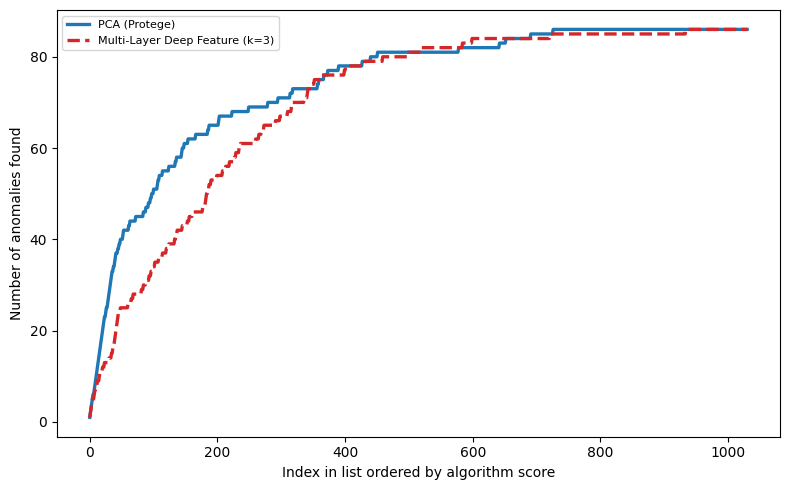

In [38]:
discovery_plot(
    methods,
    y_pc,
    highlight=['PCA (Protege)', f'Multi-Layer Deep Feature (k={best_k})']
)


## 13. Ablation: Layer 2 vs Layer 3 vs Combined

Test each layer individually to confirm that combining both layers
helps more than using either alone. Each variant uses **its own** optimal k
from the Section 11 grid (not the combined representation's k) so the
comparison isn't biased by a k mismatch.

| Variant | Features used | Dimensions | k used |
|---|---|---|---|
| Layer 2 only | Local structure | 512 | `best_k_l2` |
| Layer 3 only | Semantic content | 1024 | `best_k_l3` |
| Combined (Multi-Layer Deep Feature) | Both | 1536 | `best_k` |

In [39]:
def ablation_scores(features_whitened: np.ndarray,
                    dims: tuple,
                    index,
                    k: int = 3) -> pd.Series:
    """Score objects using only a slice of the whitened feature vector."""
    subset = features_whitened[:, dims[0]:dims[1]]
    bank   = subset.copy()
    # query == bank here (same eval-subset objects) -- exclude self-matches
    # by identity, same reasoning as Section 11's grid search.
    raw    = knn_scores(subset, bank, k=k, query_ids=index, bank_ids=index)
    return pd.Series(raw, index=index, name='score')


print(f'Ablation uses each representation\'s OWN optimal k from the Section 11 grid '
      f'(layer2: k={best_k_l2}, layer3: k={best_k_l3}, combined: k={best_k}) -- '
      f'reusing the combined representation\'s k for the layer-only slices would '
      f'bias the comparison against them.')

# s_l2 / s_l3 already computed in Section 11 at their own best k; recomputed
# here for clarity and so this cell is self-contained if re-run in isolation.
s_l2 = ablation_scores(X_pc_whitened, (0, 512),    eval_ids, k=best_k_l2)
s_l3 = ablation_scores(X_pc_whitened, (512, 1536), eval_ids, k=best_k_l3)

ablation_methods = {
    'Protege':                                 protege_scores_pc,
    f'Multi-Layer Deep Feature layer2 only (k={best_k_l2})':  s_l2,
    f'Multi-Layer Deep Feature layer3 only (k={best_k_l3})':  s_l3,
    f'Multi-Layer Deep Feature combined (k={best_k})':        patchcore_scores,
}

df_ablation = show_results(ablation_methods, y_pc, labels_pc)


Ablation uses each representation's OWN optimal k from the Section 11 grid (layer2: k=10, layer3: k=3, combined: k=3) -- reusing the combined representation's k for the layer-only slices would bias the comparison against them.
  Scoring: 1031/1031
  Scoring: 1031/1031


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
Protege,0.8946,0.6271,0.5814,0.5882
Multi-Layer Deep Feature layer3 only (k=3),0.8547,0.3779,0.3953,0.3490
Multi-Layer Deep Feature combined (k=3),0.8457,0.3704,0.3953,0.3611
Multi-Layer Deep Feature layer2 only (k=10),0.8126,0.3484,0.3837,0.3933


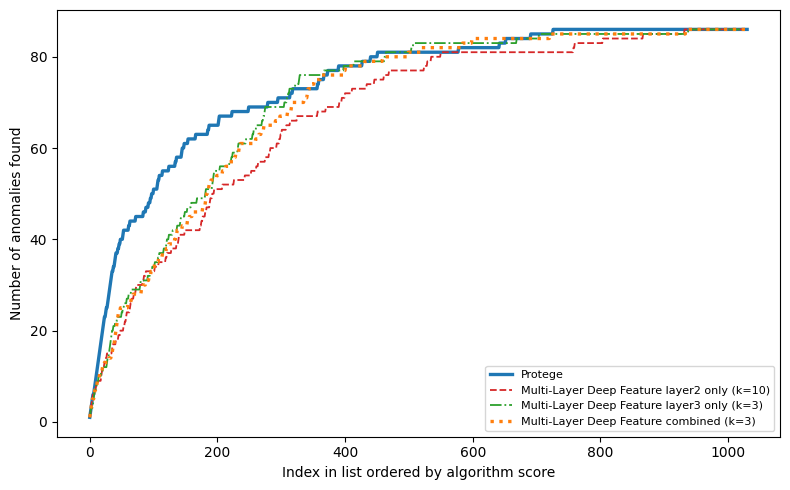

In [40]:
discovery_plot(
    ablation_methods,
    y_pc,
    highlight=['Protege', f'Multi-Layer Deep Feature combined (k={best_k})']
)

## 14. Final Comparison — Protege vs Top-3 Methods (+ Full-Set Bank)

Compute ROC-AUC for every Multi-Layer Deep Feature variant scored so far (Section 11's
eval-subset grid), pick the top-3 (excluding Protege), and plot alongside the
baseline.

We also score every representation × k combination again with the memory
bank rebuilt from the **whole extracted set** (not just the human-scored
eval subset) — Multi-Layer Deep Feature only needs labels for the query side, so the bank
itself can draw on every extracted object. The best-performing full-set-bank
variant is added to the plot explicitly, even if it doesn't crack the top-3,
since it answers a different question (does a bigger, unlabelled bank help?).

**This is Condition B**, evaluated after Condition A (Section 11): the bank
is now the full extracted corpus (all objects from Sections 4-7), not just
the labelled subset used as the bank in Condition A. Both conditions share
the same whitening transform from Section 9, so the comparison isolates
bank size/composition rather than a scaling difference.


In [41]:
all_pc_methods = {
    'PCA (Protege)':                            protege_scores_pc,
    f'Multi-Layer Deep Feature k=1 (combined)':                k_scores[1],
    f'Multi-Layer Deep Feature k=3 (combined)':                k_scores[3],
    f'Multi-Layer Deep Feature k=5 (combined)':                k_scores[5],
    f'Multi-Layer Deep Feature k=10 (combined)':               k_scores[10],
    f'Multi-Layer Deep Feature layer2 only (k={best_k_l2})':   s_l2,
    f'Multi-Layer Deep Feature layer3 only (k={best_k_l3})':   s_l3,
}

# ── Condition B: score against the WHOLE extracted corpus, not just the ──
# ── labelled eval subset (Condition A, Sections 11-13) ────────────────────
# Multi-Layer Deep Feature only needs labels for the *query* side; the memory bank itself
# can be built from every extracted object, including the ones Protege
# never scored. We query only the labelled eval subset against a bank of
# every extracted object, for every representation × k combination.
#
# Reuses `X_full_whitened`, the SAME whitening transform fit once in
# Section 9 on the full corpus -- refitting a separate scaler here would
# let Condition A and Condition B be compared under two different
# whitenings, confounding the bank-size comparison with a scaling
# difference.
N_full = len(df_pc_features)
print(f'Scoring against the full extracted set (N={N_full}) as the memory bank...')

X_query_full = X_full_whitened.loc[eval_ids].values   # query = labelled eval subset
X_bank_full  = X_full_whitened.values                 # bank  = every extracted object

full_bank_results = {}
full_bank_scores  = {}

for repr_name, (lo, hi) in REPRESENTATIONS.items():
    bank_feats  = X_bank_full[:, lo:hi]
    query_feats = X_query_full[:, lo:hi]
    for k in K_GRID:
        # query (eval_ids) is a SUBSET of the bank (df_pc_features.index) --
        # self-match exclusion is essential here too, same reasoning as
        # Sections 11 and 13.
        raw = knn_scores(query_feats, bank_feats, k=k,
                          query_ids=eval_ids, bank_ids=df_pc_features.index)
        s   = pd.Series(raw, index=eval_ids, name='score')
        full_bank_results[(repr_name, k)] = compute_metrics(y_pc, s)['roc_auc']
        full_bank_scores[(repr_name, k)]  = s

best_full_variant       = max(full_bank_results, key=full_bank_results.get)
best_full_repr, best_full_k = best_full_variant
best_full_series         = full_bank_scores[best_full_variant]

print(f'Best full-set-bank variant: representation={best_full_repr}, k={best_full_k}, '
      f'ROC-AUC={full_bank_results[best_full_variant]:.4f}')

full_bank_label = f'Multi-Layer Deep Feature {best_full_repr} (k={best_full_k}, full-set bank N={N_full})'
all_pc_methods[full_bank_label] = best_full_series

# ROC-AUC for every method
all_aucs = {
    name: compute_metrics(y_pc, s)['roc_auc']
    for name, s in all_pc_methods.items()
}

# Top-3 excluding Protege (the full-set-bank variant is a legitimate
# candidate here too -- it can win outright, not just be tacked on)
ranked = sorted(
    {k: v for k, v in all_aucs.items() if k != 'PCA (Protege)'}.items(),
    key=lambda x: x[1], reverse=True
)
top3_names = [n for n, _ in ranked[:3]]

print('\nTop-3 Multi-Layer Deep Feature variants (by ROC-AUC, eval-subset + full-set bank candidates):')
for n, auc_val in ranked[:3]:
    print(f'  {n}: {auc_val:.4f}')

# Final plot dict: Protege + top-3, and guarantee the full-set-bank variant
# is shown even if it didn't make the top-3, since "does a bigger unlabelled
# bank help?" is a distinct question from "which variant ranks highest?".
final_methods = {'PCA (Protege)': protege_scores_pc}
for n in top3_names:
    final_methods[n] = all_pc_methods[n]
if full_bank_label not in final_methods:
    final_methods[full_bank_label] = all_pc_methods[full_bank_label]

# Eval table
df_final = show_results(final_methods, y_pc, labels_pc)

# ── Headline result, stated explicitly (not left implicit in the table) ──
protege_auc_final = all_aucs['PCA (Protege)']
best_variant_name, best_variant_auc = ranked[0]
gap_to_baseline = protege_auc_final - best_variant_auc

print()
print('=' * 66)
if best_variant_auc >= protege_auc_final:
    print(f'HEADLINE: {best_variant_name} (ROC-AUC={best_variant_auc:.4f}) '
          f'MATCHES OR BEATS the Protege baseline ({protege_auc_final:.4f}).')
else:
    print(f'HEADLINE: NO Multi-Layer Deep Feature variant beats the Protege '
          f'baseline in this run.')
    print(f'  Best variant : {best_variant_name}')
    print(f'  Best ROC-AUC : {best_variant_auc:.4f}')
    print(f'  Protege ROC-AUC (baseline) : {protege_auc_final:.4f}')
    print(f'  Gap to baseline : {gap_to_baseline:+.4f} ROC-AUC (Protege ahead)')
print('=' * 66)


Scoring against the full extracted set (N=6161) as the memory bank...
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
  Scoring: 1031/1031
Best full-set-bank variant: representation=layer3, k=10, ROC-AUC=0.8610

Top-3 Multi-Layer Deep Feature variants (by ROC-AUC, eval-subset + full-set bank candidates):
  Multi-Layer Deep Feature layer3 (k=10, full-set bank N=6161): 0.8610
  Multi-Layer Deep Feature layer3 only (k=3): 0.8547
  Multi-Layer Deep Feature k=3 (combined): 0.8457


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8946,0.6271,0.5814,0.5882
"Multi-Layer Deep Feature layer3 (k=10, full-set bank N=6161)",0.8610,0.3676,0.4302,0.3593
Multi-Layer Deep Feature layer3 only (k=3),0.8547,0.3779,0.3953,0.3490
Multi-Layer Deep Feature k=3 (combined),0.8457,0.3704,0.3953,0.3611



HEADLINE: NO Multi-Layer Deep Feature variant beats the Protege baseline in this run.
  Best variant : Multi-Layer Deep Feature layer3 (k=10, full-set bank N=6161)
  Best ROC-AUC : 0.8610
  Protege ROC-AUC (baseline) : 0.8946
  Gap to baseline : +0.0336 ROC-AUC (Protege ahead)


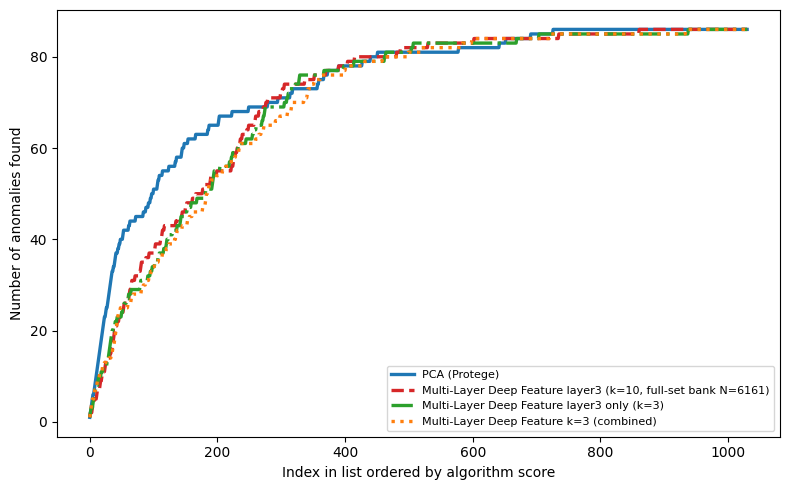

In [42]:
# Final discovery curve
discovery_plot(
    final_methods,
    y_pc,
    highlight=['PCA (Protege)'] + top3_names + [full_bank_label]
)

---
## 15. Decomposition — How Much Is the Feature, How Much Is k-NN?

Two separate ablations answer two separate questions:

- **Feature contribution** (Section 13, above): holding the scorer fixed
  (k-NN, each representation's own best k), how much does the *choice of
  feature layer* (layer2 vs layer3 vs combined) matter?
- **Scorer contribution** (this section): holding the *feature*
  representation fixed, how much does the *scorer* matter — specifically,
  how much better is k-NN (a local, density-aware distance) than the
  simplest possible alternative, distance to the memory bank's centroid
  (a single global average, with no notion of "nearest" at all)?

Both use the same Condition A setting as Sections 11-13 (memory bank = the
labelled evaluation subset), so the two ablations are directly comparable
with each other and with Section 13's numbers.


In [43]:
def centroid_scores(query: np.ndarray, bank: np.ndarray) -> np.ndarray:
    """
    Euclidean distance from each query point to the CENTROID (mean) of the
    memory bank -- the simplest anomaly scorer possible: no locality, no k,
    just "how far is this object from the average object in the bank?".

    Used to isolate how much of Multi-Layer Deep Feature's performance comes from k-NN's
    local, density-aware scoring specifically, vs. simply having good
    (whitened, deep) features to measure distance in.

    Unlike k-NN, a single mean over ~1000 points is not meaningfully
    perturbed by including the query point itself (~0.1% pull), so no
    self-match exclusion is needed here.
    """
    centroid = bank.mean(axis=0, keepdims=True)
    return np.linalg.norm(query - centroid, axis=1)


centroid_series = {}
for repr_name, (lo, hi) in REPRESENTATIONS.items():
    feats = X_pc_whitened[:, lo:hi]
    raw   = centroid_scores(feats, feats)
    centroid_series[repr_name] = pd.Series(raw, index=eval_ids, name='score')

print('Centroid-distance scores computed for layer2, layer3, combined '
      '(same Condition A eval-subset bank as Sections 11-13).')


Centroid-distance scores computed for layer2, layer3, combined (same Condition A eval-subset bank as Sections 11-13).


In [44]:
scorer_ablation_methods = {
    'Protege':                                   protege_scores_pc,
    f'Multi-Layer Deep Feature layer2, k-NN (k={best_k_l2})':   s_l2,
    'Multi-Layer Deep Feature layer2, Centroid':                 centroid_series['layer2'],
    f'Multi-Layer Deep Feature layer3, k-NN (k={best_k_l3})':   s_l3,
    'Multi-Layer Deep Feature layer3, Centroid':                 centroid_series['layer3'],
    f'Multi-Layer Deep Feature combined, k-NN (k={best_k})':    patchcore_scores,
    'Multi-Layer Deep Feature combined, Centroid':               centroid_series['combined'],
}

df_scorer_ablation = show_results(scorer_ablation_methods, y_pc, labels_pc)


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
Protege,0.8946,0.6271,0.5814,0.5882
"Multi-Layer Deep Feature layer3, k-NN (k=3)",0.8547,0.3779,0.3953,0.3490
"Multi-Layer Deep Feature combined, k-NN (k=3)",0.8457,0.3704,0.3953,0.3611
"Multi-Layer Deep Feature layer2, k-NN (k=10)",0.8126,0.3484,0.3837,0.3933
"Multi-Layer Deep Feature layer3, Centroid",0.7519,0.3573,0.3721,-0.0131
"Multi-Layer Deep Feature combined, Centroid",0.7505,0.3593,0.3605,-0.0044
"Multi-Layer Deep Feature layer2, Centroid",0.7431,0.3342,0.3256,0.0147


In [45]:
feature_aucs = {
    'layer2':   compute_metrics(y_pc, s_l2)['roc_auc'],
    'layer3':   compute_metrics(y_pc, s_l3)['roc_auc'],
    'combined': compute_metrics(y_pc, patchcore_scores)['roc_auc'],
}
centroid_aucs = {
    repr_name: compute_metrics(y_pc, s)['roc_auc']
    for repr_name, s in centroid_series.items()
}

feature_delta = max(feature_aucs.values()) - min(feature_aucs.values())

print('Feature contribution (k-NN fixed, feature representation varies):')
for r, a in feature_aucs.items():
    print(f'  {r:9s}: ROC-AUC = {a:.4f}')
print(f'  -> spread across representations: {feature_delta:.4f}')
print()

print('Scorer contribution (feature representation fixed, scorer varies):')
for r in REPRESENTATIONS:
    delta = feature_aucs[r] - centroid_aucs[r]
    print(f'  {r:9s}: k-NN {feature_aucs[r]:.4f}  vs  Centroid {centroid_aucs[r]:.4f}   '
          f'(\u0394 = {delta:+.4f})')

avg_scorer_delta = float(np.mean([feature_aucs[r] - centroid_aucs[r] for r in REPRESENTATIONS]))

print()
print(f'Average k-NN-over-Centroid gain (same features): {avg_scorer_delta:+.4f}')
print(f'Spread from feature choice alone (k-NN fixed):   {feature_delta:+.4f}')

if avg_scorer_delta > feature_delta:
    verdict = ('The choice of SCORER (k-NN vs. centroid) matters more than the choice '
               'of feature layer -- most of the gain over a naive centroid baseline '
               "comes from k-NN's local density estimate, not from which WideResNet50 "
               'layer is used.')
else:
    verdict = ('The choice of FEATURE LAYER matters more than the choice of scorer -- '
               'k-NN over a centroid baseline helps, but which representation (layer2 / '
               'layer3 / combined) is used moves the ROC-AUC more.')

print()
print(f'Verdict: {verdict}')


Feature contribution (k-NN fixed, feature representation varies):
  layer2   : ROC-AUC = 0.8126
  layer3   : ROC-AUC = 0.8547
  combined : ROC-AUC = 0.8457
  -> spread across representations: 0.0421

Scorer contribution (feature representation fixed, scorer varies):
  layer2   : k-NN 0.8126  vs  Centroid 0.7431   (Δ = +0.0695)
  layer3   : k-NN 0.8547  vs  Centroid 0.7519   (Δ = +0.1028)
  combined : k-NN 0.8457  vs  Centroid 0.7505   (Δ = +0.0951)

Average k-NN-over-Centroid gain (same features): +0.0892
Spread from feature choice alone (k-NN fixed):   +0.0421

Verdict: The choice of SCORER (k-NN vs. centroid) matters more than the choice of feature layer -- most of the gain over a naive centroid baseline comes from k-NN's local density estimate, not from which WideResNet50 layer is used.


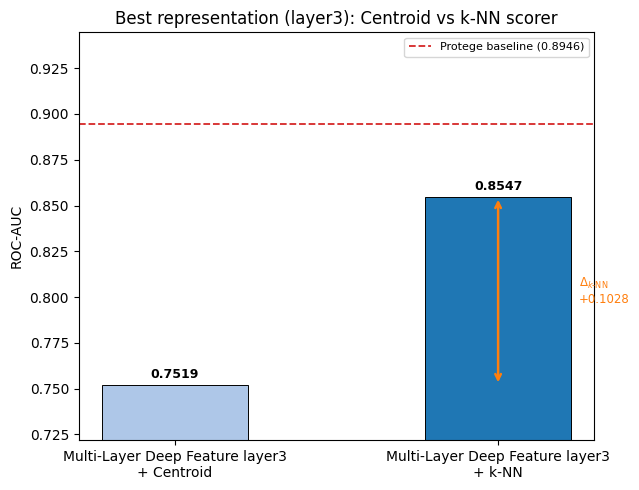

In [46]:
# ── Visualise Feature vs k-NN decomposition — TOP-1 representation only ──
best_repr = max(feature_aucs, key=feature_aucs.get)

scores_by_repr = {'layer2': s_l2, 'layer3': s_l3, 'combined': patchcore_scores}
s_pc_knn      = scores_by_repr[best_repr]
s_pc_centroid = centroid_series[best_repr]

auc_pc_knn      = feature_aucs[best_repr]
auc_pc_centroid = centroid_aucs[best_repr]
protege_auc     = compute_metrics(y_pc, protege_scores_pc)['roc_auc']

knn_gain = auc_pc_knn - auc_pc_centroid

fig, ax = plt.subplots(figsize=(6.5, 5))

labels_bar  = [f'Multi-Layer Deep Feature {best_repr}\n+ Centroid', f'Multi-Layer Deep Feature {best_repr}\n+ k-NN']
auc_vals    = [auc_pc_centroid, auc_pc_knn]
colors_bars = ['#aec7e8', '#1f77b4']
x = np.arange(len(labels_bar))
bars = ax.bar(x, auc_vals, width=0.45, color=colors_bars, edgecolor='k', linewidth=0.7)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 0.002, f'{h:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(protege_auc, color='#d62728', linestyle='--', linewidth=1.3,
           label=f'Protege baseline ({protege_auc:.4f})')

ax.annotate('', xy=(1, auc_pc_knn), xytext=(1, auc_pc_centroid),
            arrowprops=dict(arrowstyle='<->', color='#ff7f0e', lw=1.8))
ax.text(1.25, (auc_pc_knn + auc_pc_centroid) / 2,
        f'$\\Delta_{{k\\text{{-NN}}}}$\n{knn_gain:+.4f}',
        va='center', fontsize=8.5, color='#ff7f0e')

ax.set_xticks(x)
ax.set_xticklabels(labels_bar, fontsize=10)
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Best representation ({best_repr}): Centroid vs k-NN scorer')
ax.legend(fontsize=8)

y_min = min(auc_pc_centroid, auc_pc_knn, protege_auc) - 0.03
y_max = max(auc_pc_centroid, auc_pc_knn, protege_auc) + 0.05
ax.set_ylim(y_min, y_max)

ax.grid(False)
plt.tight_layout()
plt.show()